# Tesla Deliveries ML Pipeline
This notebook covers:
- Data Loading
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')


In [17]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [18]:
print(df.info())
print(df.isnull().sum())
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None
Year                    0
Month                   0
Region                  0
Model                   0
Estima

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


In [19]:
df = df.dropna()
for col in df.columns:
    if 'date' in col.lower() or 'year' in col.lower():
        try:
            df[col] = pd.to_datetime(df[col])
        except:
            pass

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,1970-01-01 00:00:00.000002023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,1970-01-01 00:00:00.000002015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,1970-01-01 00:00:00.000002019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,1970-01-01 00:00:00.000002021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,1970-01-01 00:00:00.000002016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


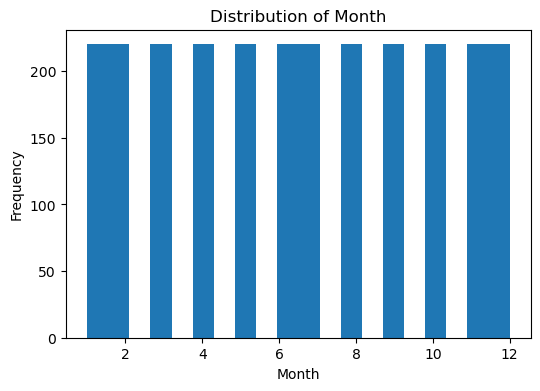

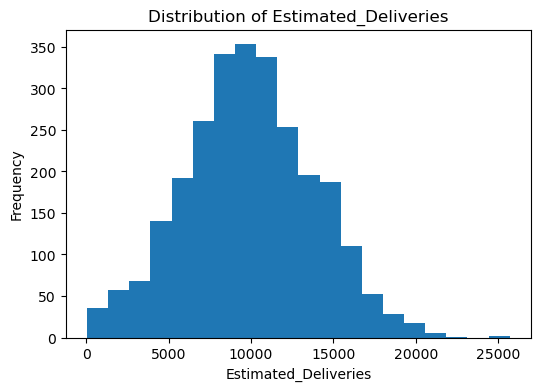

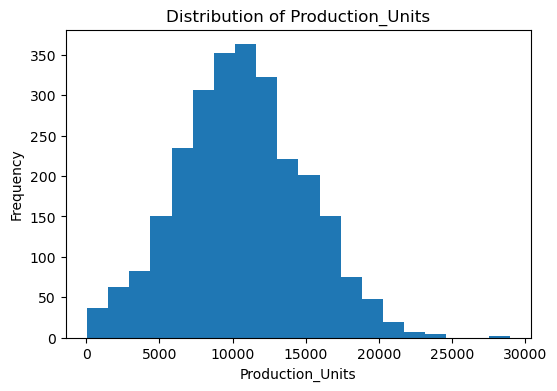

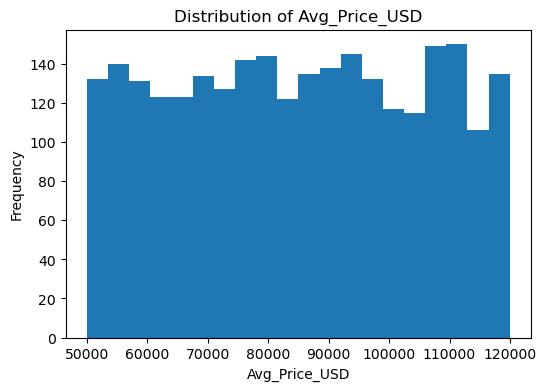

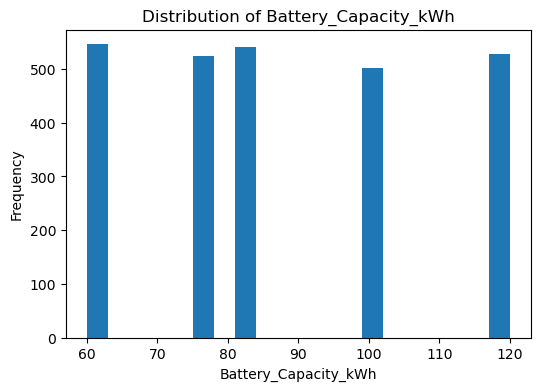

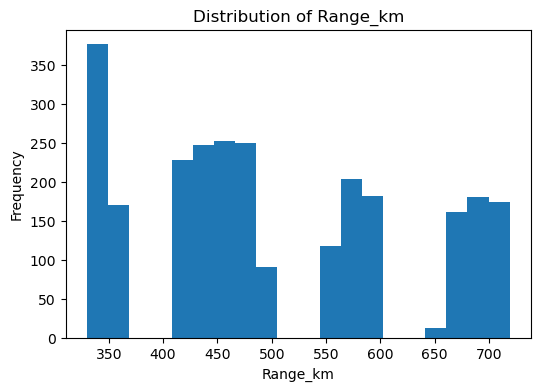

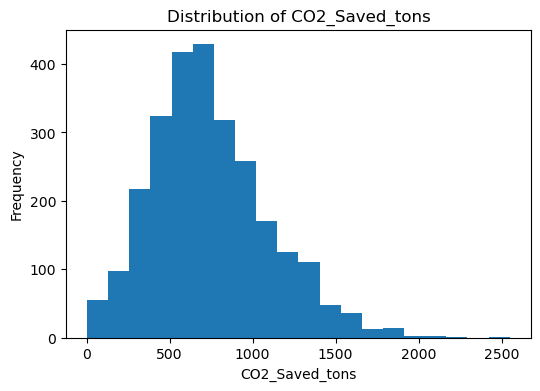

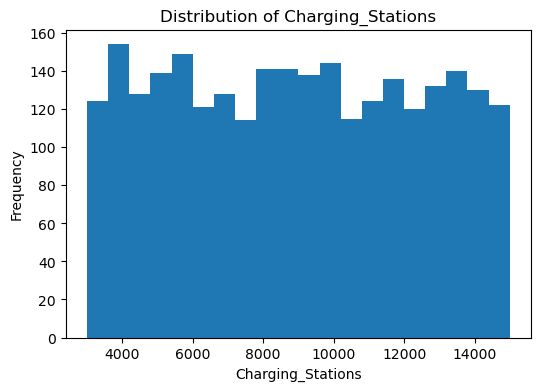

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


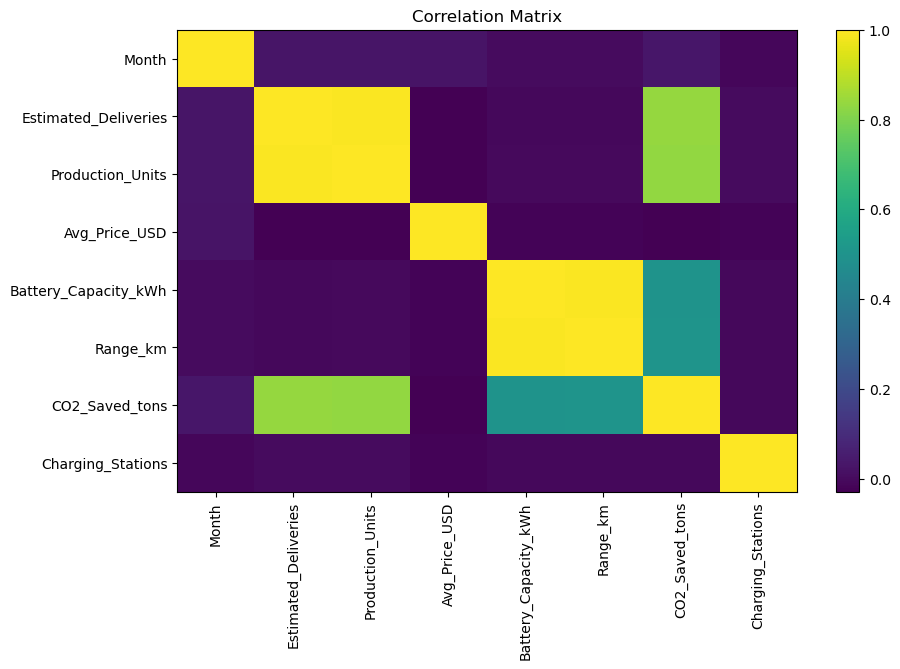

In [21]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10,6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.show()


In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,1970-01-01 00:00:00.000002023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,1970-01-01 00:00:00.000002015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,1970-01-01 00:00:00.000002019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,1970-01-01 00:00:00.000002021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,1970-01-01 00:00:00.000002016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [ ]:
target_col = df.select_dtypes(include=np.number).columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (2112, 11)
Testing Shape: (528, 11)


In [22]:
for col in X.columns:
    if X[col].dtype == 'datetime64[ns]':
        X[col] = X[col].map(pd.Timestamp.toordinal)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col].astype(str))

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 3068.557253787879
MSE: 12924109.763791477
R2 Score: -0.07461521805059412


In [ ]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Best Score: 0.00029824612923016563


In [23]:
series = df[target_col]
model = ARIMA(series, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)

print("Forecasted Values:")
print(forecast)


Forecasted Values:
2640    9073.765017
2641    9078.408736
2642    9077.713886
2643    9077.032523
2644    9076.359080
Name: predicted_mean, dtype: float64


                 Feature  Importance
9         CO2_Saved_tons    0.201526
6          Avg_Price_USD    0.195717
8               Range_km    0.193058
4   Estimated_Deliveries    0.127968
5       Production_Units    0.117646
1                  Month    0.080859
2                 Region    0.027858
3                  Model    0.026784
10           Source_Type    0.024647
7   Battery_Capacity_kWh    0.003937
0                   Year    0.000000


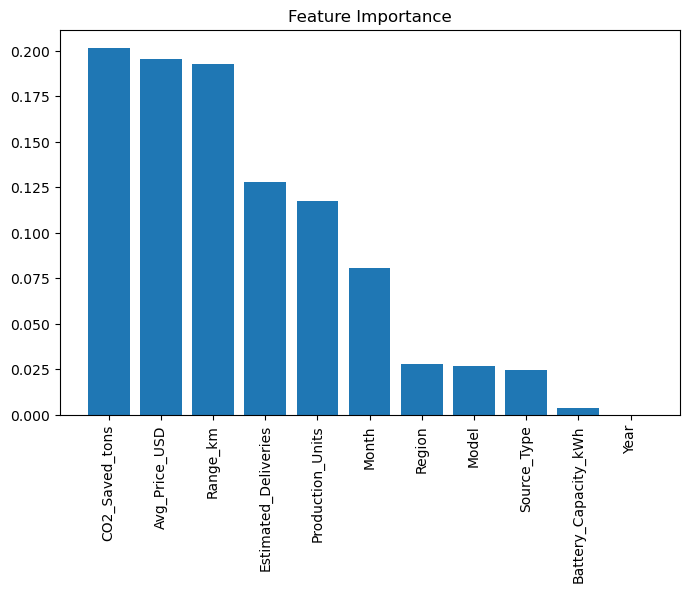

In [ ]:
best_model = grid.best_estimator_

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()
